# Tarefa 2: NumPy Models (Sem Scikit-Learn)

Notebook equivalente ao original, mas sem qualquer import/uso de scikit-learn.
Inclui split estratificado, TF-IDF e métricas implementados em NumPy/Python.

## 0. Imports e Configuração

In [1]:
import sys
import re
from collections import Counter, defaultdict

sys.path.append('../models/numpy_models')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activation import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from metrics import accuracy

np.random.seed(42)

## 1. Utilitários (Sem sklearn)

Split estratificado, one-hot, TF-IDF e métricas implementados de raiz.

In [2]:
def one_hot_encode(labels):
    classes = sorted(pd.Series(labels).unique().tolist())
    class_to_idx = {c: i for i, c in enumerate(classes)}
    y = np.zeros((len(labels), len(classes)), dtype=int)
    for i, lbl in enumerate(labels):
        y[i, class_to_idx[lbl]] = 1
    return y, classes, class_to_idx

def stratified_split_indices(labels, test_size=0.2, random_state=42):
    rng = np.random.RandomState(random_state)
    labels = np.array(labels)
    unique_classes = np.unique(labels)

    train_idx = []
    test_idx = []

    for c in unique_classes:
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)
        n_test = int(round(len(idx) * test_size))
        n_test = max(1, min(len(idx) - 1, n_test)) if len(idx) > 1 else len(idx)

        test_idx.extend(idx[:n_test].tolist())
        train_idx.extend(idx[n_test:].tolist())

    train_idx = np.array(train_idx)
    test_idx = np.array(test_idx)
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return train_idx, test_idx

EN_STOPWORDS = {
    'the', 'a', 'an', 'and', 'or', 'to', 'of', 'in', 'on', 'for', 'with',
    'at', 'by', 'from', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'as', 'that', 'this', 'it', 'its', 'into', 'than', 'then', 'their', 'they'
}

class NumpyTfidfVectorizer:
    def __init__(self, max_features=5000, analyzer='word', ngram_range=(1, 1), stop_words=None):
        self.max_features = max_features
        self.analyzer = analyzer
        self.ngram_range = ngram_range
        self.stop_words = stop_words
        self.vocab_ = {}
        self.idf_ = None

    def _word_tokens(self, text):
        tokens = re.findall(r"[A-Za-z0-9']+", str(text).lower())
        if self.stop_words == 'english':
            tokens = [t for t in tokens if t not in EN_STOPWORDS]
        return tokens

    def _char_tokens(self, text):
        return list(str(text).lower())

    def _make_ngrams(self, tokens):
        n_min, n_max = self.ngram_range
        grams = []
        if self.analyzer == 'char':
            text = ''.join(tokens)
            for n in range(n_min, n_max + 1):
                if len(text) >= n:
                    grams.extend([text[i:i+n] for i in range(len(text) - n + 1)])
        else:
            for n in range(n_min, n_max + 1):
                if len(tokens) >= n:
                    grams.extend([' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)])
        return grams

    def _extract_terms(self, text):
        if self.analyzer == 'char':
            base = self._char_tokens(text)
        else:
            base = self._word_tokens(text)
        return self._make_ngrams(base)

    def fit(self, docs):
        df_counts = Counter()
        tf_counts = Counter()
        n_docs = len(docs)

        for doc in docs:
            terms = self._extract_terms(doc)
            if not terms:
                continue
            tf_counts.update(terms)
            df_counts.update(set(terms))

        if self.max_features is not None:
            candidates = sorted(tf_counts.items(), key=lambda x: x[1], reverse=True)[:self.max_features]
            vocab_terms = [t for t, _ in candidates]
        else:
            vocab_terms = list(tf_counts.keys())

        self.vocab_ = {t: i for i, t in enumerate(vocab_terms)}

        idf = np.zeros(len(self.vocab_), dtype=float)
        for term, j in self.vocab_.items():
            df_t = df_counts.get(term, 0)
            idf[j] = np.log((1 + n_docs) / (1 + df_t)) + 1.0
        self.idf_ = idf
        return self

    def transform(self, docs):
        X = np.zeros((len(docs), len(self.vocab_)), dtype=float)

        for i, doc in enumerate(docs):
            terms = self._extract_terms(doc)
            if not terms:
                continue

            counts = Counter(t for t in terms if t in self.vocab_)
            total = sum(counts.values())
            if total == 0:
                continue

            for term, c in counts.items():
                j = self.vocab_[term]
                tf = c / total
                X[i, j] = tf * self.idf_[j]

            norm = np.linalg.norm(X[i])
            if norm > 0:
                X[i] /= norm

        return X

    def fit_transform(self, docs):
        return self.fit(docs).transform(docs)

def confusion_matrix_np(y_true, y_pred, labels):
    idx = {c: i for i, c in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1
    return cm

def accuracy_score_np(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float((y_true == y_pred).mean())

def matthews_corrcoef_multiclass(y_true, y_pred, labels=None):
    if labels is None:
        labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix_np(y_true, y_pred, labels)

    t_k = cm.sum(axis=1)
    p_k = cm.sum(axis=0)
    c = np.trace(cm)
    s = cm.sum()

    num = c * s - np.dot(t_k, p_k)
    den = np.sqrt((s**2 - np.dot(p_k, p_k)) * (s**2 - np.dot(t_k, t_k)))
    return 0.0 if den == 0 else float(num / den)

def classification_report_np(y_true, y_pred, labels):
    cm = confusion_matrix_np(y_true, y_pred, labels)
    lines = []
    lines.append(f"{'class':<14}{'precision':>10}{'recall':>10}{'f1-score':>10}{'support':>10}")

    precisions, recalls, f1s, supports = [], [], [], []

    for i, label in enumerate(labels):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        support = cm[i, :].sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        supports.append(support)

        lines.append(f"{label:<14}{precision:>10.4f}{recall:>10.4f}{f1:>10.4f}{support:>10d}")

    total = int(np.sum(supports))
    macro_p = float(np.mean(precisions)) if precisions else 0.0
    macro_r = float(np.mean(recalls)) if recalls else 0.0
    macro_f = float(np.mean(f1s)) if f1s else 0.0

    w_p = float(np.average(precisions, weights=supports)) if total > 0 else 0.0
    w_r = float(np.average(recalls, weights=supports)) if total > 0 else 0.0
    w_f = float(np.average(f1s, weights=supports)) if total > 0 else 0.0

    lines.append('')
    lines.append(f"{'macro avg':<14}{macro_p:>10.4f}{macro_r:>10.4f}{macro_f:>10.4f}{total:>10d}")
    lines.append(f"{'weighted avg':<14}{w_p:>10.4f}{w_r:>10.4f}{w_f:>10.4f}{total:>10d}")
    return '\n'.join(lines)

## 2. Carregamento dos Dados

In [3]:
df = pd.read_csv('../data/dataset_limpo.csv', sep=';').dropna(subset=['Text', 'Label'])
df_exemplos = pd.read_csv('../data/dataset-exemplos.csv', sep=';').dropna(subset=['Text', 'Label'])

print('Distribuição dataset treino:')
print(df['Label'].value_counts())
print(f'\nTotal: {len(df)} amostras')

print('\nDistribuição dataset professor:')
print(df_exemplos['Label'].value_counts())
print(f'Total: {len(df_exemplos)} amostras')

Distribuição dataset treino:
Label
Human        999
OpenAI       999
Google       999
Meta         999
Anthropic    999
Name: count, dtype: int64

Total: 4995 amostras

Distribuição dataset professor:
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64
Total: 125 amostras


## 3. Preparação para Modelo 1 e Modelo 2

In [4]:
df_model1 = df.copy()
df_model1['Label_Bin'] = np.where(df_model1['Label'] == 'Human', 'Human', 'IA')

df_model2 = df[df['Label'] != 'Human'].reset_index(drop=True)

print('Distribuição Modelo 1 (Human vs IA):')
print(df_model1['Label_Bin'].value_counts())
print('\nDistribuição Modelo 2 (IAs):')
print(df_model2['Label'].value_counts())

X1 = df_model1['Text'].values
y1_raw = df_model1['Label_Bin'].values
y1_encoded, classes1, _ = one_hot_encode(y1_raw)

idx1_train, idx1_temp = stratified_split_indices(y1_raw, test_size=0.2, random_state=42)
idx1_val, idx1_test = stratified_split_indices(y1_raw[idx1_temp], test_size=0.5, random_state=42)
idx1_val = idx1_temp[idx1_val]
idx1_test = idx1_temp[idx1_test]

X1_train, y1_train = X1[idx1_train], y1_encoded[idx1_train]
X1_val, y1_val = X1[idx1_val], y1_encoded[idx1_val]
X1_test, y1_test = X1[idx1_test], y1_encoded[idx1_test]

tfidf1_word = NumpyTfidfVectorizer(max_features=2500, analyzer='word', ngram_range=(1, 2), stop_words='english')
tfidf1_char = NumpyTfidfVectorizer(max_features=2500, analyzer='char', ngram_range=(3, 5))

X1_train_tfidf = np.hstack([tfidf1_word.fit_transform(X1_train), tfidf1_char.fit_transform(X1_train)])
X1_val_tfidf = np.hstack([tfidf1_word.transform(X1_val), tfidf1_char.transform(X1_val)])
X1_test_tfidf = np.hstack([tfidf1_word.transform(X1_test), tfidf1_char.transform(X1_test)])

X2 = df_model2['Text'].values
y2_raw = df_model2['Label'].values
y2_encoded, classes2, _ = one_hot_encode(y2_raw)

idx2_train, idx2_temp = stratified_split_indices(y2_raw, test_size=0.2, random_state=42)
idx2_val, idx2_test = stratified_split_indices(y2_raw[idx2_temp], test_size=0.5, random_state=42)
idx2_val = idx2_temp[idx2_val]
idx2_test = idx2_temp[idx2_test]

X2_train, y2_train = X2[idx2_train], y2_encoded[idx2_train]
X2_val, y2_val = X2[idx2_val], y2_encoded[idx2_val]
X2_test, y2_test = X2[idx2_test], y2_encoded[idx2_test]

tfidf2 = NumpyTfidfVectorizer(max_features=5000, analyzer='char', ngram_range=(3, 5))
X2_train_tfidf = tfidf2.fit_transform(X2_train)
X2_val_tfidf = tfidf2.transform(X2_val)
X2_test_tfidf = tfidf2.transform(X2_test)

print(f'\nModelo 1 features: {X1_train_tfidf.shape[1]}')
print(f'Modelo 2 features: {X2_train_tfidf.shape[1]}')
print(f'Classes M1: {classes1}')
print(f'Classes M2: {classes2}')

Distribuição Modelo 1 (Human vs IA):
Label_Bin
IA       3996
Human     999
Name: count, dtype: int64

Distribuição Modelo 2 (IAs):
Label
OpenAI       999
Google       999
Meta         999
Anthropic    999
Name: count, dtype: int64

Modelo 1 features: 5000
Modelo 2 features: 5000
Classes M1: ['Human', 'IA']
Classes M2: ['Anthropic', 'Google', 'Meta', 'OpenAI']


## 4. Wrappers de Dataset

In [5]:
class TextDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_dataset1 = TextDataset(X1_train_tfidf, y1_train)
val_dataset1 = TextDataset(X1_val_tfidf, y1_val)
test_dataset1 = TextDataset(X1_test_tfidf, y1_test)

train_dataset2 = TextDataset(X2_train_tfidf, y2_train)
val_dataset2 = TextDataset(X2_val_tfidf, y2_val)
test_dataset2 = TextDataset(X2_test_tfidf, y2_test)

## 5. Baselines

In [6]:
baseline1 = NeuralNetwork(epochs=100, batch_size=64, learning_rate=0.05, verbose=True, loss=CategoricalCrossEntropy, metric=accuracy)
baseline1.add(DenseLayer(len(classes1), input_shape=(X1_train_tfidf.shape[1],)))
baseline1.add(SoftmaxActivation())
print('Treinar Baseline 1 (Human vs IA)')
baseline1.fit(train_dataset1, val_dataset=val_dataset1)

baseline2 = NeuralNetwork(epochs=100, batch_size=64, learning_rate=0.05, verbose=True, loss=CategoricalCrossEntropy, metric=accuracy)
baseline2.add(DenseLayer(len(classes2), input_shape=(X2_train_tfidf.shape[1],)))
baseline2.add(SoftmaxActivation())
print('Treinar Baseline 2 (IAs)')
baseline2.fit(train_dataset2, val_dataset=val_dataset2)

Treinar Baseline 1 (Human vs IA)
Epoch 1/100 - loss: 0.5590 - val_loss: 0.4882 - accuracy: 0.7790
Epoch 10/100 - loss: 0.4238 - val_loss: 0.4259 - accuracy: 0.8001
Epoch 20/100 - loss: 0.3722 - val_loss: 0.3797 - accuracy: 0.8021
Epoch 30/100 - loss: 0.3344 - val_loss: 0.3459 - accuracy: 0.8243
Epoch 40/100 - loss: 0.3056 - val_loss: 0.3200 - accuracy: 0.8526
Epoch 50/100 - loss: 0.2828 - val_loss: 0.2997 - accuracy: 0.8749
Epoch 60/100 - loss: 0.2643 - val_loss: 0.2832 - accuracy: 0.8929
Epoch 70/100 - loss: 0.2488 - val_loss: 0.2693 - accuracy: 0.9069
Epoch 80/100 - loss: 0.2356 - val_loss: 0.2574 - accuracy: 0.9174
Epoch 90/100 - loss: 0.2243 - val_loss: 0.2473 - accuracy: 0.9249
Epoch 100/100 - loss: 0.2142 - val_loss: 0.2384 - accuracy: 0.9304
Treinar Baseline 2 (IAs)
Epoch 1/100 - loss: 1.3842 - val_loss: 1.3803 - accuracy: 0.2897
Epoch 10/100 - loss: 1.3104 - val_loss: 1.3138 - accuracy: 0.7153
Epoch 20/100 - loss: 1.2397 - val_loss: 1.2506 - accuracy: 0.7650
Epoch 30/100 - loss

## 6. DNNs

In [7]:
loss_weighted = CategoricalCrossEntropy(class_weights=[4.0, 1.0]) # [Human, IA]

net1 = NeuralNetwork(epochs=50, batch_size=64, learning_rate=0.01, verbose=True, loss=loss_weighted, metric=accuracy)
net1.add(DenseLayer(128, input_shape=(X1_train_tfidf.shape[1],)))
net1.add(ReLUActivation())
net1.add(DropoutLayer(0.4))
net1.add(DenseLayer(64))
net1.add(ReLUActivation())
net1.add(DropoutLayer(0.2))
net1.add(DenseLayer(len(classes1)))
net1.add(SoftmaxActivation())
print('Treinar DNN 1 (Human vs IA)')
net1.fit(train_dataset1, val_dataset=val_dataset1)

net2 = NeuralNetwork(epochs=100, batch_size=64, learning_rate=0.03, verbose=True, loss=CategoricalCrossEntropy, metric=accuracy)
net2.add(DenseLayer(64, input_shape=(X2_train_tfidf.shape[1],)))
net2.add(ReLUActivation())
net2.add(DropoutLayer(0.2))
net2.add(DenseLayer(len(classes2)))
net2.add(SoftmaxActivation())
print('Treinar DNN 2 (Classificação de IAs)')
net2.fit(train_dataset2, val_dataset=val_dataset2)

Treinar DNN 1 (Human vs IA)
Epoch 1/50 - loss: 1.1083 - val_loss: 1.1065 - accuracy: 0.3228
Epoch 10/50 - loss: 0.9419 - val_loss: 0.9215 - accuracy: 0.7985
Epoch 20/50 - loss: 0.4727 - val_loss: 0.4657 - accuracy: 0.9044
Epoch 30/50 - loss: 0.2539 - val_loss: 0.2908 - accuracy: 0.9545
Epoch 40/50 - loss: 0.1605 - val_loss: 0.2349 - accuracy: 0.9707
Epoch 50/50 - loss: 0.1033 - val_loss: 0.2171 - accuracy: 0.9827
Treinar DNN 2 (Classificação de IAs)
Epoch 1/100 - loss: 1.3852 - val_loss: 1.3823 - accuracy: 0.2516
Epoch 10/100 - loss: 1.3044 - val_loss: 1.3042 - accuracy: 0.5932
Epoch 20/100 - loss: 1.1494 - val_loss: 1.1544 - accuracy: 0.6546
Epoch 30/100 - loss: 0.9785 - val_loss: 0.9979 - accuracy: 0.7259
Epoch 40/100 - loss: 0.8458 - val_loss: 0.8741 - accuracy: 0.7688
Epoch 50/100 - loss: 0.7350 - val_loss: 0.7730 - accuracy: 0.8063
Epoch 60/100 - loss: 0.6447 - val_loss: 0.6903 - accuracy: 0.8273
Epoch 70/100 - loss: 0.5688 - val_loss: 0.6228 - accuracy: 0.8470
Epoch 80/100 - loss

## 7. Funções de Avaliação

In [8]:
def evaluate_model(model, dataset, classes, name=''):
    probs = model.predict(dataset)
    y_pred_idx = np.argmax(probs, axis=1)
    y_true_idx = np.argmax(dataset.y, axis=1)
    y_pred = [classes[i] for i in y_pred_idx]
    y_true = [classes[i] for i in y_true_idx]
    acc = accuracy_score_np(y_true, y_pred)
    mcc = matthews_corrcoef_multiclass(y_true, y_pred, labels=classes)
    print(f'[{name}] Accuracy: {acc*100:.2f}% | MCC: {mcc:.4f}')
    return y_true, y_pred, acc, mcc

print('=== Avaliação interna dos baselines ===')
evaluate_model(baseline1, test_dataset1, classes1, 'Baseline1')
evaluate_model(baseline2, test_dataset2, classes2, 'Baseline2')

print('=== Avaliação interna das DNNs ===')
evaluate_model(net1, test_dataset1, classes1, 'DNN1')
evaluate_model(net2, test_dataset2, classes2, 'DNN2')

=== Avaliação interna dos baselines ===
[Baseline1] Accuracy: 91.80% | MCC: 0.7285
[Baseline2] Accuracy: 76.00% | MCC: 0.6817
=== Avaliação interna das DNNs ===
[DNN1] Accuracy: 96.00% | MCC: 0.8750
[DNN2] Accuracy: 83.25% | MCC: 0.7780


(['OpenAI',
  'OpenAI',
  'Meta',
  'Anthropic',
  'Google',
  'Anthropic',
  'Meta',
  'Meta',
  'Anthropic',
  'Anthropic',
  'OpenAI',
  'Meta',
  'Google',
  'Meta',
  'Meta',
  'OpenAI',
  'Meta',
  'Meta',
  'Anthropic',
  'Anthropic',
  'Anthropic',
  'Google',
  'Anthropic',
  'Google',
  'OpenAI',
  'Google',
  'Anthropic',
  'Meta',
  'OpenAI',
  'Google',
  'Anthropic',
  'OpenAI',
  'OpenAI',
  'OpenAI',
  'Anthropic',
  'Meta',
  'Google',
  'OpenAI',
  'Meta',
  'Anthropic',
  'OpenAI',
  'Anthropic',
  'Google',
  'Meta',
  'OpenAI',
  'Google',
  'Google',
  'Google',
  'Google',
  'OpenAI',
  'Google',
  'Google',
  'Meta',
  'Google',
  'Anthropic',
  'Google',
  'Anthropic',
  'Google',
  'Meta',
  'OpenAI',
  'Meta',
  'Google',
  'OpenAI',
  'Anthropic',
  'OpenAI',
  'Anthropic',
  'Google',
  'OpenAI',
  'Anthropic',
  'OpenAI',
  'OpenAI',
  'OpenAI',
  'Meta',
  'OpenAI',
  'OpenAI',
  'Anthropic',
  'OpenAI',
  'OpenAI',
  'OpenAI',
  'Meta',
  'Meta',
  'Meta

## 8. Pipeline Divide and Conquer

In [9]:
def pipeline_predict(texts, tfidf1_word, tfidf1_char, net1, tfidf2, net2, classes1, classes2):
    texts_list = list(texts) if isinstance(texts, pd.Series) else list(texts)

    X1_w = tfidf1_word.transform(texts_list)
    X1_c = tfidf1_char.transform(texts_list)
    X1_tfidf = np.hstack([X1_w, X1_c])
    dummy_y1 = np.zeros((len(X1_tfidf), len(classes1)))
    probs1 = net1.predict(TextDataset(X1_tfidf, dummy_y1))
    preds1 = [classes1[np.argmax(p)] for p in probs1]

    ia_indices = [i for i, c in enumerate(preds1) if c != 'Human']
    ia_preds = {}

    if ia_indices:
        ia_texts = [texts_list[i] for i in ia_indices]
        X2_tfidf = tfidf2.transform(ia_texts)
        dummy_y2 = np.zeros((len(X2_tfidf), len(classes2)))
        probs2 = net2.predict(TextDataset(X2_tfidf, dummy_y2))
        for local_i, global_i in enumerate(ia_indices):
            ia_preds[global_i] = classes2[np.argmax(probs2[local_i])]

    final_preds = []
    for i in range(len(preds1)):
        if preds1[i] == 'Human':
            final_preds.append('Human')
        else:
            final_preds.append(ia_preds.get(i, 'Human'))
    return final_preds

## 9. Avaliação Global

Accuracy Global (Teste Interno): 90.80%
MCC Global (Teste Interno): 0.8853

Relatório de Classificação:
class          precision    recall  f1-score   support
Anthropic         0.9586    0.9267    0.9424       150
Google            0.9108    0.9533    0.9316       150
Human             0.9363    0.9800    0.9577       150
Meta              0.8581    0.8867    0.8721       150
OpenAI            0.8750    0.7933    0.8322       150

macro avg         0.9078    0.9080    0.9072       750
weighted avg      0.9078    0.9080    0.9072       750


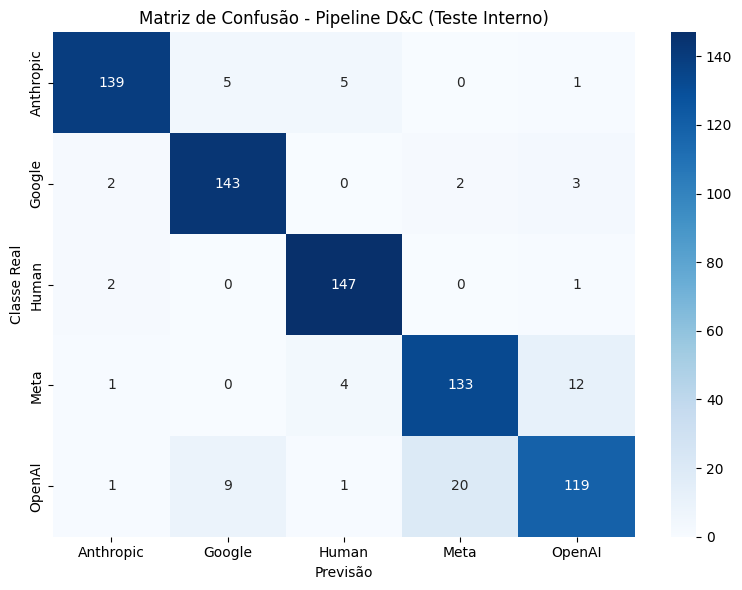

In [10]:
# 15% estratificado para avaliação interna global
idx_train_eval, idx_test_eval = stratified_split_indices(df['Label'].values, test_size=0.15, random_state=101)
df_test_eval = df.iloc[idx_test_eval]

X_eval = df_test_eval['Text'].values
y_eval = df_test_eval['Label'].values

preds_eval = pipeline_predict(X_eval, tfidf1_word, tfidf1_char, net1, tfidf2, net2, classes1, classes2)
all_classes = sorted(df['Label'].unique().tolist())

acc_global = accuracy_score_np(y_eval, preds_eval)
mcc_global = matthews_corrcoef_multiclass(y_eval, preds_eval, labels=all_classes)
print(f'Accuracy Global (Teste Interno): {acc_global*100:.2f}%')
print(f'MCC Global (Teste Interno): {mcc_global:.4f}')
print('\nRelatório de Classificação:')
print(classification_report_np(y_eval, preds_eval, labels=all_classes))

cm = confusion_matrix_np(y_eval, preds_eval, labels=all_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=all_classes, yticklabels=all_classes)
plt.title('Matriz de Confusão - Pipeline D&C (Teste Interno)')
plt.ylabel('Classe Real')
plt.xlabel('Previsão')
plt.tight_layout()
plt.show()

Accuracy (Dataset Professor): 61.60%
MCC (Dataset Professor): 0.4823

Relatório de Classificação:
class          precision    recall  f1-score   support
Anthropic         0.6667    0.2609    0.3750        23
Google            0.4400    0.6875    0.5366        16
Human             0.7759    0.8654    0.8182        52
Meta              0.3750    0.3529    0.3636        17
OpenAI            0.5294    0.5294    0.5294        17

macro avg         0.5574    0.5392    0.5246       125
weighted avg      0.6247    0.6160    0.5995       125


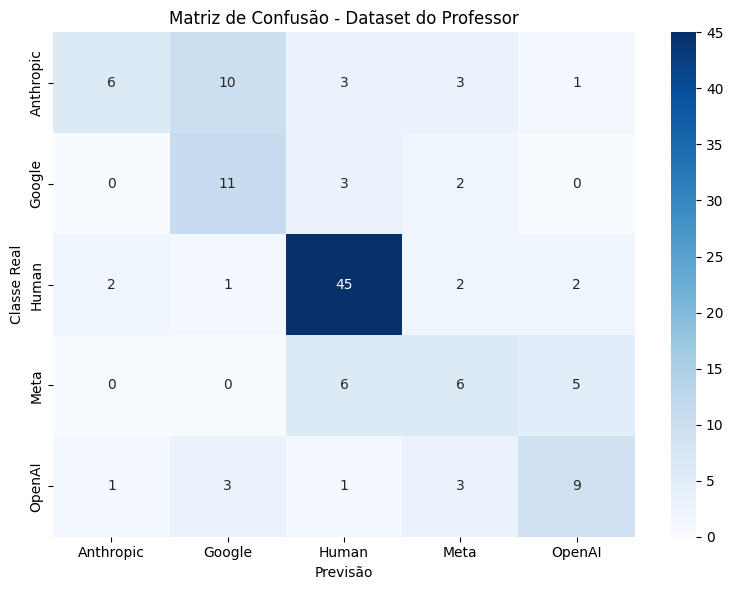

In [11]:
X_ex = df_exemplos['Text'].values
y_ex = df_exemplos['Label'].values

preds_ex = pipeline_predict(X_ex, tfidf1_word, tfidf1_char, net1, tfidf2, net2, classes1, classes2)
all_classes_ex = sorted(df_exemplos['Label'].unique().tolist())

acc_ex = accuracy_score_np(y_ex, preds_ex)
mcc_ex = matthews_corrcoef_multiclass(y_ex, preds_ex, labels=all_classes_ex)
print(f'Accuracy (Dataset Professor): {acc_ex*100:.2f}%')
print(f'MCC (Dataset Professor): {mcc_ex:.4f}')
print('\nRelatório de Classificação:')
print(classification_report_np(y_ex, preds_ex, labels=all_classes_ex))

cm_ex = confusion_matrix_np(y_ex, preds_ex, labels=all_classes_ex)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ex, annot=True, fmt='d', cmap='Blues', xticklabels=all_classes_ex, yticklabels=all_classes_ex)
plt.title('Matriz de Confusão - Dataset do Professor')
plt.ylabel('Classe Real')
plt.xlabel('Previsão')
plt.tight_layout()
plt.show()

Accuracy Binária: 84.00% | MCC: 0.6793

Relatório Binário:
class          precision    recall  f1-score   support
Human             0.7759    0.8654    0.8182        52
IA                0.8955    0.8219    0.8571        73

macro avg         0.8357    0.8437    0.8377       125
weighted avg      0.8457    0.8400    0.8409       125


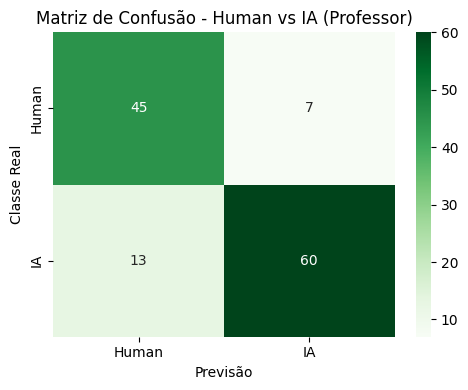

In [12]:
y_ex_bin = np.where(df_exemplos['Label'].values == 'Human', 'Human', 'IA')

X_ex_tfidf1 = np.hstack([tfidf1_word.transform(X_ex), tfidf1_char.transform(X_ex)])
dummy_y_ex1 = np.zeros((len(X_ex), len(classes1)))
probs_ex1 = net1.predict(TextDataset(X_ex_tfidf1, dummy_y_ex1))
preds_ex_bin = [classes1[np.argmax(p)] for p in probs_ex1]

acc_bin = accuracy_score_np(y_ex_bin, preds_ex_bin)
mcc_bin = matthews_corrcoef_multiclass(y_ex_bin, preds_ex_bin, labels=['Human', 'IA'])
print(f'Accuracy Binária: {acc_bin*100:.2f}% | MCC: {mcc_bin:.4f}')
print('\nRelatório Binário:')
print(classification_report_np(y_ex_bin, preds_ex_bin, labels=['Human', 'IA']))

cm_bin = confusion_matrix_np(y_ex_bin, preds_ex_bin, labels=['Human', 'IA'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Greens', xticklabels=['Human', 'IA'], yticklabels=['Human', 'IA'])
plt.title('Matriz de Confusão - Human vs IA (Professor)')
plt.ylabel('Classe Real')
plt.xlabel('Previsão')
plt.tight_layout()
plt.show()

## 5. Geração da Submissão A (Dataset de Teste Final)

Carregamos o dataset cego (`subm1.csv`), aplicamos a mesma pipeline D&C e geramos o ficheiro de submissão.

A formatação do ficheiro segue a diretriz: `subm1-g<ng>-<curso>-A.csv`

In [14]:
import os

df_subm = pd.read_csv('../subm1.csv', sep=';')

# Aplicar a pipeline D&C ao dataset cego
preds_subm = pipeline_predict(
    df_subm['Text'],
    tfidf1_word, tfidf1_char, net1,
    tfidf2, net2,
    classes1, classes2
)

df_subm['Label'] = preds_subm
df_final = df_subm[['ID', 'Text', 'Label']]

output_dir = '../Subm1'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'subm1-g3-MIA-A.csv')

df_final.to_csv(output_path, sep=';', index=False)
print(f"Submissão gerada com sucesso em: {output_path}")
print("---- Distribuição ----")
print(df_final['Label'].value_counts())


Submissão gerada com sucesso em: ../Subm1/subm1-g3-MIA-A.csv
---- Distribuição ----
Label
Human        66
Meta         28
OpenAI       21
Google       19
Anthropic    16
Name: count, dtype: int64
